[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/rl-basics/blob/main/RL_basics_frozenlake.ipynb)

# Reinforcement Learning Basics with Frozen Lake

**What you will learn in this notebook**

1. The Gymnasium library and its interface: `make`, `reset`, `step`, `render`, `close`
2. The core RL vocabulary: **environment, state, action, reward, episode, cumulative reward (return), policy**
3. The difference between a **deterministic** world (`is_slippery=False`) and a **stochastic** world (`is_slippery=True`) — and why that difference is the reason reinforcement *learning* exists at all.

We study the same tiny world twice. First with firm ice, where every move does exactly what you ask. Then with slippery ice, where moves only *sometimes* do what you ask. The same solution that is perfect in the first world will fail in the second, and understanding why is the first real insight of RL.

## 1. The idea of reinforcement learning

Reinforcement learning is learning by **interaction**. There is no teacher giving correct answers; there is only an environment giving feedback.

The whole field rests on one loop:

1. The **agent** observes the current **state** of the environment.
2. It chooses an **action**.
3. The environment responds with a **reward** and a new state.
4. Repeat.

The agent's goal is to choose actions that maximize the **total reward collected over time**, not just the next reward. A sequence of interactions from a starting state to an ending state is called an **episode** — one full attempt at the task.

**Our task: Frozen Lake.** An agent stands on the top-left tile of a 4x4 frozen lake and must reach the gift on the bottom-right tile. Some tiles are holes: stepping on one ends the episode with nothing. The layout:

```
S F F F        S = start          F = frozen (safe)
F H F H        H = hole (episode ends, reward 0)
F F F H        G = gift (episode ends, reward +1)
H F F G
```

The reward is **sparse**: 0 for every move, +1 only for the move that reaches the gift. The agent gets no hints along the way — success or nothing.

In [10]:
# Install Gymnasium (the maintained successor of OpenAI Gym) and its renderer.
%pip install -qq gymnasium==1.3.0 pygame

import gymnasium as gym
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


## 2. Part 1 — The deterministic world (`is_slippery=False`)

We begin with firm ice: every action does exactly what it says. Deterministic worlds are the right starting point because we can verify by hand that the code behaves as the math promises.

### 2.1 The environment

The **environment** is the world the agent lives in. Gymnasium gives us hundreds of ready-made environments through one function, `gym.make`. Every environment, from this 16-tile lake to an Atari game, is then controlled through the same three methods: `reset()`, `step()`, `render()`. Learn the interface once, use it everywhere.

In [11]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

### 2.2 States and the state space

A **state** is a complete description of the current situation. Here it is a single integer from 0 to 15, numbering the tiles left to right, top to bottom:

$$s = row \times 4 + column, \qquad row, column \in \{0,1,2,3\}$$

So the start is state 0, the gift is state 15, and `divmod(s, 4)` recovers the (row, column) view. The set of all possible states is the **state space**, stored in `env.observation_space`.

`reset()` starts a new episode: it places the agent on the start tile and returns the initial state plus an `info` dictionary. Passing a `seed` makes runs reproducible.

In [12]:
state, info = env.reset(seed=42)

print(f"Initial state: {state}, which is tile {divmod(state, 4)} as (row, col)")
print(f"State space:   {env.observation_space}")

Initial state: 0, which is tile (0, 0) as (row, col)
State space:   Discrete(16)


### 2.3 Seeing the world: `render()`

`render()` returns the current picture of the lake as a pixel array. The picture is for *us*: the agent itself only ever sees the state number.

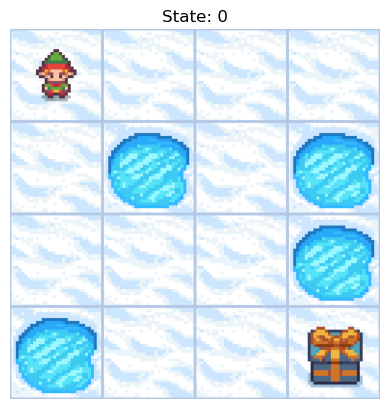

In [13]:
plt.imshow(env.render())
plt.axis("off")
plt.title(f"State: {state}")
plt.show()

### 2.4 Actions and the action space

An **action** is one of the moves available to the agent. Frozen Lake has four, encoded as integers:

| Action | Meaning |
|---|---|
| 0 | move LEFT |
| 1 | move DOWN |
| 2 | move RIGHT |
| 3 | move UP |

**Common mistake:** every grid environment numbers its actions differently (many mazes use 0 = UP). Always check the documentation before assuming.

The set of all actions is the **action space**, `env.action_space`. Calling `.sample()` on it draws a random legal action — the simplest possible decision-maker.

In [14]:
print(f"Action space: {env.action_space}")
print(f"A random action: {env.action_space.sample()}")

Action space: Discrete(4)
A random action: 0


### 2.5 Acting in the world: `step()`

`step(action)` executes the action and advances the world by one tick. It returns five values:

| Returned value | Meaning |
|---|---|
| `next_state` | the tile the agent is on after the move |
| `reward` | feedback for that move (0, or +1 at the gift) |
| `terminated` | `True` if the task itself ended: gift reached or hole entered |
| `truncated` | `True` if a time limit (100 steps here) cut the episode short |
| `info` | extra details, usually ignored |

The episode is over when *either* flag is `True`, so we always combine them: `done = terminated or truncated`. (Older Gym returned a single `done` flag; Gymnasium splits it because "the task ended" and "we ran out of time" mean different things.)

Let us take one step down and verify the world is deterministic:

In [15]:
action = 1  # DOWN
next_state, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated

print(f"State after moving down: {next_state}  (expected 0 + 4 = 4)")
print(f"Reward: {reward}")
print(f"Episode over? {done}")

State after moving down: 4  (expected 0 + 4 = 4)
Reward: 0
Episode over? False


### 2.6 An episode: one full attempt

An **episode** is the full sequence of states, actions and rewards from `reset()` until the episode ends:

$$\tau = S_0, A_0, R_1, S_1, A_1, R_2, \dots, R_T, S_T$$

Let us run one episode where the agent acts **randomly**, and record everything that happens. This loop — observe, act, step, repeat until done — is the skeleton of every RL program you will ever write.

In [16]:
state, info = env.reset(seed=42)
done = False
episode = []

while not done:
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    episode.append((state, action, reward, next_state))
    state = next_state

print(f"The episode lasted {len(episode)} steps:")
for s, a, r, s_next in episode:
    print(f"  state {s:2d} --action {a}--> state {s_next:2d},  reward {r}")

# The last reward reveals how the episode ended: +1 means gift, 0 means hole.
outcome = "reached the GIFT" if reward == 1 else "fell into a HOLE"
print(f"\nOutcome: the agent {outcome}.")

The episode lasted 3 steps:
  state  0 --action 1--> state  4,  reward 0
  state  4 --action 0--> state  4,  reward 0
  state  4 --action 2--> state  5,  reward 0

Outcome: the agent fell into a HOLE.


### 2.7 Cumulative reward: the return

The agent does not care about a single reward — it cares about the **total reward accumulated over the episode**. This total, computed from time *t* onward, is called the **return**:

$$G_0 = R_1 + \gamma R_2 + \gamma^2 R_3 + \dots + \gamma^{T-1} R_T$$

The **discount factor** $\gamma \in (0, 1]$ makes rewards arriving later count slightly less. Why discount at all? Two reasons:

1. It expresses a preference for reaching good outcomes *sooner*.
2. It keeps the sum finite even for tasks that could go on forever.

In Frozen Lake every reward is 0 except possibly the last one, so the long sum collapses to just two cases — a useful check on understanding:

- agent fails (hole or time limit): $G_0 = 0$
- agent reaches the gift at step $T$: $G_0 = \gamma^{T-1}$

So the return simultaneously encodes *whether* the agent succeeded and *how fast*: shorter successful paths give returns closer to 1. Let us verify with $\gamma = 0.99$:

In [17]:
state, info = env.reset()
done = False
gamma = 0.99
G = 0.0
t = 0

while not done:
    action = env.action_space.sample()
    _, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    G += gamma**t * reward   # each reward discounted by how late it arrives
    t += 1

print(f"Episode length: {t} steps, return G_0 = {G:.4f}")
if G > 0:
    print(f"Check: gamma^(T-1) = 0.99^{t-1} = {gamma**(t-1):.4f}  (matches)")
else:
    print("A return of 0 means the agent never reached the gift.")

Episode length: 3 steps, return G_0 = 0.0000
A return of 0 means the agent never reached the gift.


### 2.8 A policy — and a perfect one for firm ice

A **policy** is the agent's rule for choosing actions: for every state, which action (or which probabilities over actions) to take. The policy is *the thing we are ultimately trying to find*.

On firm ice we do not need any learning — we can solve the lake by inspection. Reading the map, one safe path from start to gift is:

```
DOWN, DOWN, RIGHT, DOWN, RIGHT, RIGHT
(0 -> 4 -> 8 -> 9 -> 13 -> 14 -> 15)
```

Let us hard-code this plan and confirm it works **every single time**. Success in a deterministic world is a matter of memorization, not learning.

In [18]:
def run_fixed_plan(env, plan):
    """Execute a fixed list of actions; return the total (undiscounted) reward."""
    state, info = env.reset()
    total_reward = 0
    for action in plan:
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break
    return total_reward


plan = [1, 1, 2, 1, 2, 2]   # DOWN, DOWN, RIGHT, DOWN, RIGHT, RIGHT

successes = sum(run_fixed_plan(env, plan) for _ in range(1000))
print(f"Fixed plan on FIRM ice: {successes} successes out of 1000 episodes")

Fixed plan on FIRM ice: 1000 successes out of 1000 episodes


1000 out of 1000. In a deterministic world, a memorized sequence of actions is a complete solution. Hold that thought — we are about to break it.

## 3. Part 2 — The stochastic world (`is_slippery=True`)

Now the ice is slippery. The rule, straight from the environment's definition: when the agent chooses an action, it moves in the **intended direction with probability 1/3**, and in each of the two **perpendicular** directions with probability 1/3 each. Choose DOWN, and you go DOWN, LEFT, or RIGHT — each one third of the time.

Formally, the transition function is no longer a certainty but a probability distribution:

$$p(s' \mid s, a) \; < \; 1 \quad \text{for most } (s, a)$$

This one change models something universal: in the real world, **actions have uncertain outcomes**. A robot's wheel slips, a trade executes at a different price, a treatment works on some patients and not others. Stochasticity is the normal case; determinism is the exception.

In [19]:
env_slippery = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")

### 3.1 Seeing the randomness

Take the *same* action from the *same* state several times and watch where the agent lands:

In [20]:
print("From state 0, choosing DOWN (action 1) ten separate times:")
for trial in range(10):
    env_slippery.reset(seed=trial)   # different seed -> different slip outcome
    next_state, *_ = env_slippery.step(1)
    print(f"  trial {trial}: landed in state {next_state}")

From state 0, choosing DOWN (action 1) ten separate times:
  trial 0: landed in state 0
  trial 1: landed in state 1
  trial 2: landed in state 0
  trial 3: landed in state 0
  trial 4: landed in state 4
  trial 5: landed in state 1
  trial 6: landed in state 4
  trial 7: landed in state 1
  trial 8: landed in state 1
  trial 9: landed in state 0


Same state, same action, different results. Three outcomes are possible: state 4 (the slide went DOWN as intended), state 1 (slipped RIGHT), and state 0 (slipped LEFT — but the wall is there, so the agent stays in place). Slipping is always perpendicular to the intended direction, never opposite to it.

The agent can no longer predict its own next position — it can only reason about probabilities.

### 3.2 The fixed plan meets slippery ice

Here is the crucial experiment. Our plan was **perfect** on firm ice. Run it on slippery ice:

In [21]:
successes = sum(run_fixed_plan(env_slippery, plan) for _ in range(1000))
print(f"Fixed plan on SLIPPERY ice: {successes} successes out of 1000 episodes")

Fixed plan on SLIPPERY ice: 7 successes out of 1000 episodes


The success rate collapses from 100% to a few percent. Why? A fixed plan is **open-loop**: it dictates the 3rd action assuming the first two moves went as intended. On slippery ice they usually did not, so from step one onward the plan is issuing instructions for a position the agent is no longer in — often marching it straight into a hole.

**This is the central lesson of the notebook.** What the agent needs is not a *sequence of actions* but a *policy*: a rule that looks at the **current state** — wherever the slipping actually put us — and chooses an action for *that* state. A policy is **closed-loop**: it reacts to reality instead of assuming it.

### 3.3 Comparing three agents

Let us measure the success rate (fraction of episodes reaching the gift) of:

1. the **fixed plan** on slippery ice (open-loop),
2. a **random policy** on slippery ice (closed-loop but clueless),
3. and for reference, the fixed plan on firm ice.

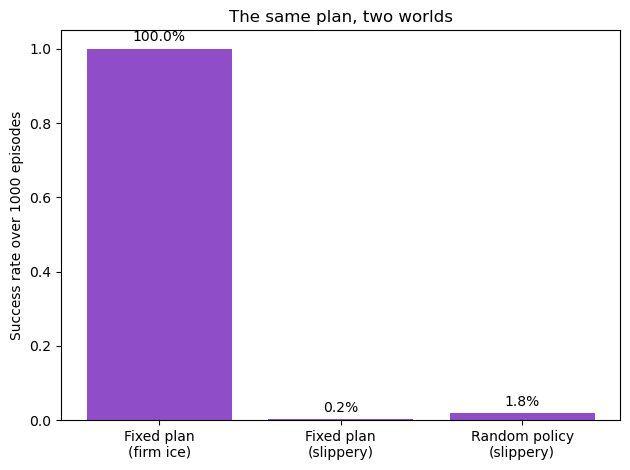

In [22]:
def run_random_policy(env):
    state, info = env.reset()
    done = False
    total_reward = 0
    while not done:
        state, reward, terminated, truncated, _ = env.step(env.action_space.sample())
        done = terminated or truncated
        total_reward += reward
    return total_reward


N = 1000
results = {
    "Fixed plan\n(firm ice)":     np.mean([run_fixed_plan(env, plan) for _ in range(N)]),
    "Fixed plan\n(slippery)":     np.mean([run_fixed_plan(env_slippery, plan) for _ in range(N)]),
    "Random policy\n(slippery)":  np.mean([run_random_policy(env_slippery) for _ in range(N)]),
}

plt.bar(results.keys(), results.values(), color="#7B2FBE", alpha=0.85)
plt.ylabel(f"Success rate over {N} episodes")
plt.title("The same plan, two worlds")
plt.ylim(0, 1.05)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

### 3.4 Peeking under the hood: the transition model

Frozen Lake actually exposes its internal transition probabilities through `env.unwrapped.P`. For each state and action it lists every possible outcome as a tuple `(probability, next_state, reward, terminated)`. Compare the two worlds for the same state-action pair:

In [23]:
s, a = 0, 1   # state 0, action DOWN

print("Firm ice     P[0][DOWN]:", env.unwrapped.P[s][a])
print("Slippery ice P[0][DOWN]:", env_slippery.unwrapped.P[s][a])

Firm ice     P[0][DOWN]: [(1.0, 4, 0, False)]
Slippery ice P[0][DOWN]: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 4, 0, False), (0.33333333333333337, 1, 0, False)]


On firm ice there is a single outcome with probability 1.0. On slippery ice there are three outcomes with probability 1/3 each — exactly the rule stated above, now confirmed by the environment itself.

Two remarks worth carrying forward:

1. Algorithms that *read* this table to compute the best policy exist — that is **dynamic programming**, the next lesson. But in most real problems no such table is available, and the agent must learn purely from experienced transitions. That is what Monte Carlo and temporal-difference methods do.
2. This is why we needed `terminated` vs `truncated`: the table's `terminated` flag is part of the world's definition, while truncation is an outside intervention.

In [24]:
env.close()
env_slippery.close()

## 4. Summary

| Concept | Meaning | In code |
|---|---|---|
| Environment | the world the agent interacts with | `gym.make("FrozenLake-v1", ...)` |
| State | complete description of the current situation (tile 0–15) | returned by `reset()` and `step()` |
| Action | a move available to the agent (0–3) | passed to `env.step(action)` |
| Reward | one-step feedback (0, or +1 at the gift) | 2nd value returned by `step()` |
| Episode | one full attempt, from `reset()` to termination/truncation | the `while not done:` loop |
| Cumulative reward (return) | $G_0 = \sum_t \gamma^t R_{t+1}$, what the agent maximizes | accumulated inside the loop |
| Policy | a rule mapping each state to an action | the function the next lessons will *learn* |
| Deterministic vs stochastic | whether $p(s' \mid s,a)$ is 1 or a distribution | `is_slippery=False` / `True` |

**The takeaway.** On firm ice, a memorized plan is enough — no learning required. On slippery ice, the same plan fails, because it ignores where the agent actually ends up. The agent needs a **policy** that responds to every state it might land in, and finding good policies in uncertain worlds is precisely what the algorithms in the coming notebooks — dynamic programming, Monte Carlo, SARSA, Q-Learning — are for.